# Projeto 23: Transferência de Aprendizagem


1. Baixando e descompactando as imagens

Link para o dataset: http://web.mit.edu/torralba/www/indoor.html

In [2]:
# Download do arquivo

In [3]:
!wget http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar

--2026-04-20 01:54:28--  http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Resolving groups.csail.mit.edu (groups.csail.mit.edu)... 128.52.131.233
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar [following]
--2026-04-20 01:54:28--  https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2592010240 (2.4G) [application/x-tar]
Saving to: ‘indoorCVPR_09.tar’

indoorCVPR_09.tar   100%[===================>]   2.41G  10.9MB/s    in 3m 51s  

2026-04-20 01:58:19 (10.7 MB/s) - ‘indoorCVPR_09.tar’ saved [2592010240/2592010240]



In [4]:
!tar -xvf indoorCVPR_09.tar

A saída de streaming foi truncada nas últimas 5000 linhas.
Images/mall/cover_home3.jpg
Images/mall/CP67791.jpg
Images/mall/crocker_galleria_735089.jpg
Images/mall/mall1.jpg
Images/mall/d8.jpg
Images/mall/deira_city_centre_dubai_08.jpg
Images/mall/dungarv_new_mall.jpg
Images/mall/latham_circle_mall_16.jpg
Images/mall/eastridg1.jpg
Images/mall/IMG_6449.jpg
Images/mall/main_boutique_b.jpg
Images/mall/easyfranchise_centre_commercial_1.jpg
Images/mall/ins42.jpg
Images/mall/mall14.jpg
Images/mall/eaton_centre_2001_03.jpg
Images/mall/ins43.jpg
Images/mall/mall17.jpg
Images/mall/full_shopping_Central_1.jpg
Images/mall/galleria.jpg
Images/mall/galleria1.jpg
Images/mall/galleria2.jpg
Images/mall/Galleria_003.jpg
Images/mall/laurel_mall_06.jpg
Images/mall/Galleria_1.jpg
Images/mall/galleria_san_federico_nr_109_2_n1.jpg
Images/mall/ins23.jpg
Images/mall/ins44.jpg
Images/mall/mall18.jpg
Images/mall/galleria_vittorio_emanuele_ii_milan_mlgalar.jpg
Images/mall/ins45.jpg
Images/mall/mall19.jpg
Images/m

# Nova seção

**Dataset é considerado como indoor scene recognition** , contém imagens internas, pertencentes. Com 77 categorias, locais dos prédios, banheiro, adega de vinhos, 500 mil imagens.

figuras salvas no colab
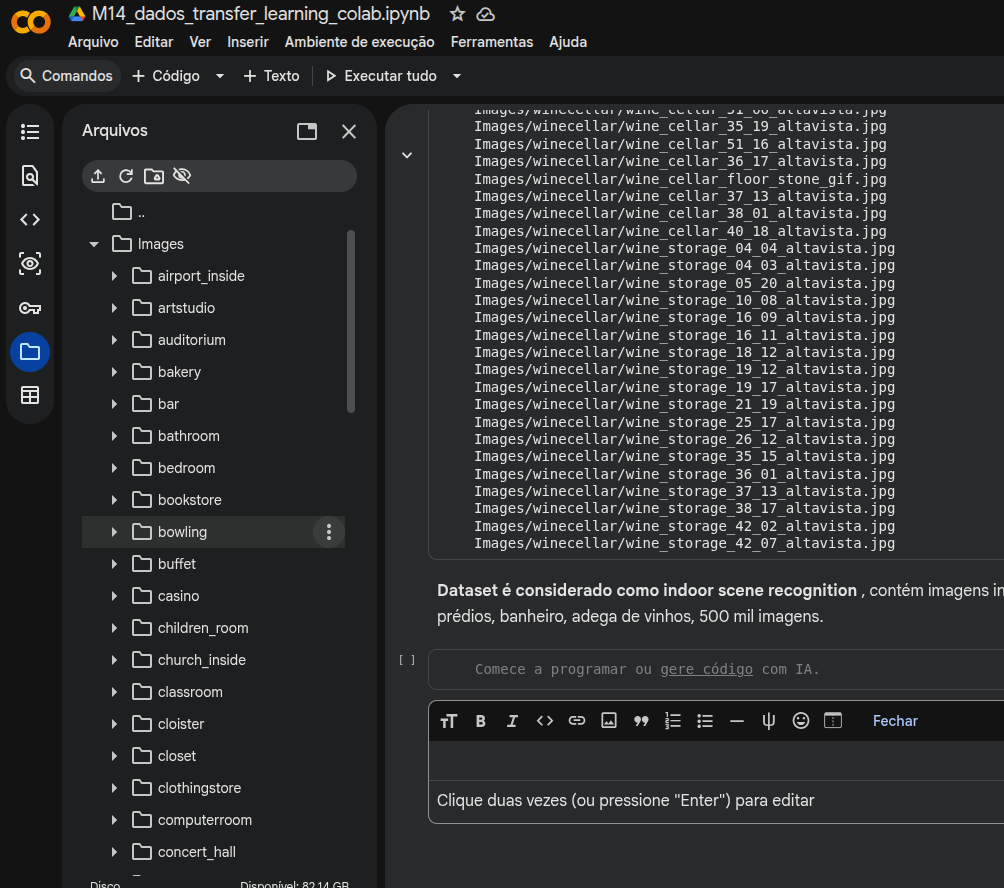

## 2. Preparando as pastas dos datasets

In [5]:
import os



In [6]:
# 1. Contagem de arquivos por pasta:
# O os.walk percorre a pasta 'Images' e todas as suas subpastas.
# Para cada pasta encontrada, o len(files) conta quantos arquivos existem dentro dela.
# O 'if len(files) > 0' garante que ele só adicione na lista as pastas que não estão vazias.
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]
print(num_files_per_folder) # Ex: [100, 150, 120] (Quantidade de imagens em cada classe)

# 2. Identificação dos nomes das pastas (Categorias):
# Aqui ele busca apenas os nomes dos diretórios dentro de 'Images'.
# O '[0]' no final pega apenas a primeira lista de pastas encontrada (geralmente as pastas das classes).
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]  # conter diretório
print('folders')
print(folders) # Ex: [fastfood_restaurant', 'bedroom', 'dining_room']

[116, 662, 274, 101, 269, 197, 127, 101, 233, 107, 107, 103, 513, 108, 135, 135, 175, 380, 157, 706, 539, 144, 515, 120, 101, 125, 114, 101, 127, 176, 276, 131, 103, 151, 213, 249, 608, 405, 110, 457, 140, 168, 153, 166, 180, 258, 506, 103, 213, 176, 106, 347, 384, 346, 155, 174, 239, 734, 103, 112, 113, 111, 116, 102, 604, 109, 231]
folders
['fastfood_restaurant', 'bedroom', 'dining_room', 'lobby', 'winecellar', 'bathroom', 'kindergarden', 'greenhouse', 'meeting_room', 'library', 'restaurant_kitchen', 'prisoncell', 'restaurant', 'studiomusic', 'closet', 'operating_room', 'movietheater', 'bookstore', 'jewelleryshop', 'livingroom', 'subway', 'nursery', 'casino', 'cloister', 'hospitalroom', 'laboratorywet', 'computerroom', 'elevator', 'gameroom', 'auditorium', 'laundromat', 'dentaloffice', 'florist', 'waitingroom', 'grocerystore', 'locker_room', 'airport_inside', 'bakery', 'videostore', 'inside_subway', 'artstudio', 'museum', 'trainstation', 'tv_studio', 'church_inside', 'deli', 'warehou

In [7]:
#from google.colab import drive
#drive.mount('/content/drive')

In [8]:
# raiz , diretório e arquivo => root, dirs, files

In [9]:
num_files_per_folder[:5], folders[:5]

([116, 662, 274, 101, 269],
 ['fastfood_restaurant', 'bedroom', 'dining_room', 'lobby', 'winecellar'])

In [10]:
num_files_per_folder[:7], folders[:7]

([116, 662, 274, 101, 269, 197, 127],
 ['fastfood_restaurant',
  'bedroom',
  'dining_room',
  'lobby',
  'winecellar',
  'bathroom',
  'kindergarden'])

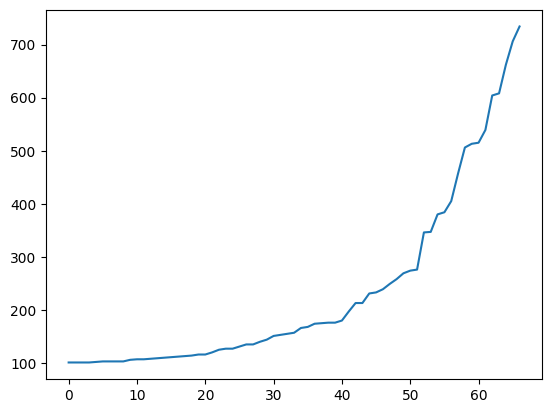

In [11]:
# visualizar o número dos arquivos por pastas, em ordem crescente

import matplotlib.pyplot as plt
plt.plot(sorted(num_files_per_folder))

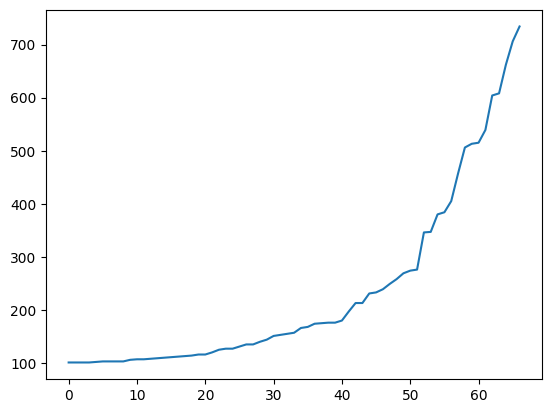

In [12]:
# 1. Ordenação (sorted):
# O 'sorted()' organiza os números da sua lista (num_files_per_folder) do menor para o maior.
# Isso facilita ver a diferença entre a classe que tem menos imagens e a que tem mais.
dados_ordenados = sorted(num_files_per_folder)

# 2. Plotagem (plt.plot):
# Como você passou apenas uma lista, o Matplotlib usa o índice (0, 1, 2...) no eixo X
# e a quantidade de arquivos no eixo Y.
plt.plot(dados_ordenados)

# Exibe o gráfico na tela
plt.show()

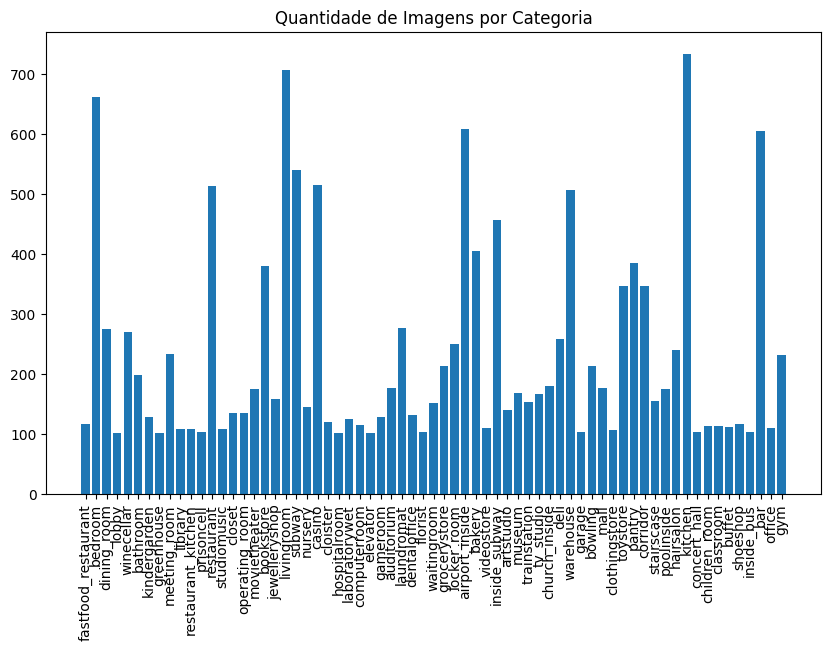

In [13]:
# Dica: Gráfico de barras com nomes
plt.figure(figsize=(10, 6))
plt.bar(folders, num_files_per_folder)
plt.xticks(rotation=90) # Rotaciona os nomes para não amontoar
plt.title('Quantidade de Imagens por Categoria')
plt.show()

In [14]:
import numpy as np
# quantas pastas tem mais de 600 imagens
sum(np.array(num_files_per_folder) > 600)

np.int64(5)

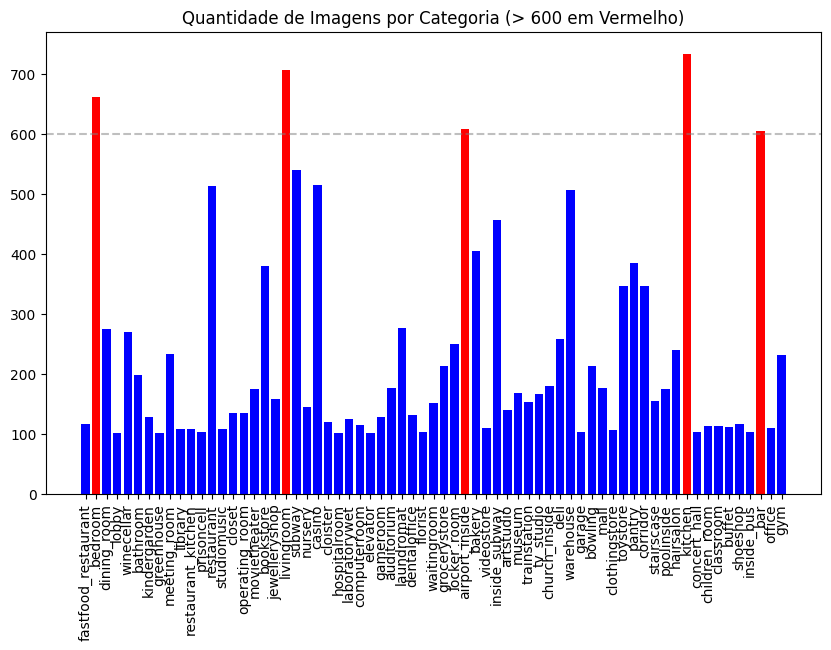

In [15]:
# 1. Criando a lista de cores condicional:
# Usamos uma "list comprehension": se o valor for > 600, a cor é 'red' (vermelho),
# caso contrário, usamos 'blue' (azul) para as demais.
cores = ['red' if qtd > 600 else 'blue' for qtd in num_files_per_folder]

# 2. Gerando o gráfico com as cores customizadas:
plt.figure(figsize=(10, 6))

# Passamos a lista 'cores' para o parâmetro color
plt.bar(folders, num_files_per_folder, color = cores)

plt.xticks(rotation=90)
plt.title('Quantidade de Imagens por Categoria (> 600 em Vermelho)')

# 3. Opcional: Adicionar uma linha de corte em 600 para facilitar a visualização
plt.axhline(y=600, color='gray', linestyle='--', alpha=0.5)

plt.show()

In [16]:
# comparar com uma lista para ver valores acima de 600 imagens

In [17]:
mask = np.array(num_files_per_folder) > 600
folders_to_keep = list(np.array(folders)[mask])
folders_to_keep # pasta que usaremos

[np.str_('bedroom'),
 np.str_('livingroom'),
 np.str_('airport_inside'),
 np.str_('kitchen'),
 np.str_('bar')]

In [18]:
import shutil
[shutil.rmtree('Images/' + folder) for folder in folders if folder not in folders_to_keep]; # manter as pastas com mais de 600 imagens

agora há apenas as pastas de interesse, com mais de 600 imagens na pasta

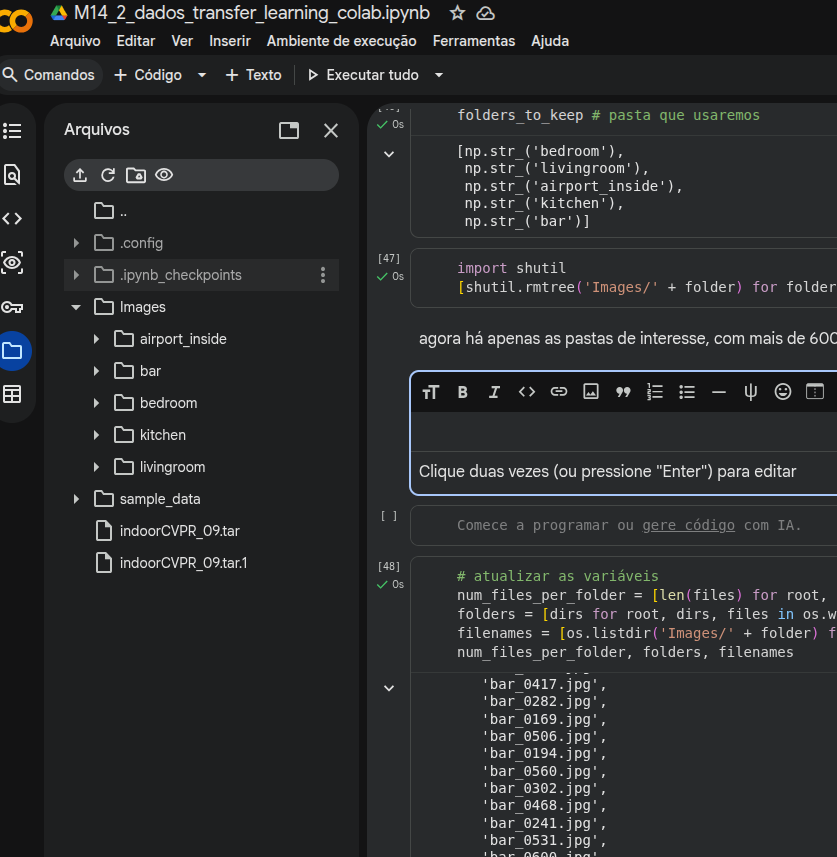

In [19]:
# atualizar as variáveis
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]
filenames = [os.listdir('Images/' + folder) for folder in folders]
num_files_per_folder, folders, filenames # nomes dos arquivos

([662, 706, 608, 734, 604],
 ['bedroom', 'livingroom', 'airport_inside', 'kitchen', 'bar'],
 [['IMG_1245.jpg',
   'img_0076.jpg',
   'pasadena_IMG_0150.jpg',
   'indoor_0418.jpg',
   'int486.jpg',
   'indoor_0332.jpg',
   'indoor_0289.jpg',
   'int186.jpg',
   'D02.jpg',
   'int208.jpg',
   'IMG_0994.jpg',
   'indoor_0190.jpg',
   'room301.jpg',
   'room409.jpg',
   'int262.jpg',
   'int184.jpg',
   'indoor_0056.jpg',
   'int231.jpg',
   'int701.jpg',
   'int819.jpg',
   'b23.jpg',
   'int534.jpg',
   'int271.jpg',
   'int152.jpg',
   'indoor_0323.jpg',
   'indoor_0428.jpg',
   'IMG_3264.jpg',
   'room358.jpg',
   'IMG_5744.jpg',
   'int215.jpg',
   'b13.jpg',
   'kamer1g.jpg',
   'chambre1.jpg',
   'int199.jpg',
   'indoor_0305.jpg',
   'int496.jpg',
   'int273.jpg',
   'room158.jpg',
   'indoor_0192.jpg',
   'IMG_0026.jpg',
   'indoor_0503.jpg',
   'OriginalWingRoom15_large.jpg',
   'indoor_0145.jpg',
   'int100.jpg',
   'indoor_0515.jpg',
   'room237.jpg',
   'S03.jpg',
   'int616.j

In [20]:
# seleção das categorias mais numerosas para a análise

## 2.2 Separação das imagens treino e teste

In [21]:
np.random.seed(23)
# separar 20% para teste, não ter amostra repetida replace = False
files_to_test = [sorted(np.random.choice(files, round(num_files * 0.2), replace = False)) for files, num_files in zip(filenames, num_files_per_folder)]
files_to_test # lista quais foram selecionados



[[np.str_('2333_2.jpg'),
  np.str_('28042007_001.jpg'),
  np.str_('Gold_Class_600SS_Room_King.jpg'),
  np.str_('IMG_0025.jpg'),
  np.str_('IMG_1246.jpg'),
  np.str_('IMG_1566.jpg'),
  np.str_('IMG_1682.jpg'),
  np.str_('IMG_1683.jpg'),
  np.str_('IMG_2338.jpg'),
  np.str_('IMG_2434.jpg'),
  np.str_('IMG_2830.jpg'),
  np.str_('IMG_3206.jpg'),
  np.str_('IMG_3264.jpg'),
  np.str_('IMG_3265.jpg'),
  np.str_('IMG_4830.jpg'),
  np.str_('IMG_9641.jpg'),
  np.str_('IMG_9642.jpg'),
  np.str_('IMG_9643.jpg'),
  np.str_('IMG_9644.jpg'),
  np.str_('Madison-room.jpg'),
  np.str_('N190002.jpg'),
  np.str_('S02.jpg'),
  np.str_('S03.jpg'),
  np.str_('VA_02_03_9773_33_l.jpg'),
  np.str_('at_00_05_8293_15_l.jpg'),
  np.str_('b15.jpg'),
  np.str_('b18.jpg'),
  np.str_('b19.jpg'),
  np.str_('b29.jpg'),
  np.str_('b30.jpg'),
  np.str_('b7.jpg'),
  np.str_('bed172.jpg'),
  np.str_('bed2.jpg'),
  np.str_('bed8.jpg'),
  np.str_('cdMC1107.jpg'),
  np.str_('chambre22.jpg'),
  np.str_('child4.jpg'),
  np.str_(

In [ ]:
os.mkdir('Images/test/') # criando a pasta que será salva
[os.mkdir('Images/test/' + folder) for folder in folders];
[shutil.move('Images/' + folder + '/' + file, 'Images/test/' + folder + '/' + file) for files, folder in zip(files_to_test, folders) for file in files];

In [22]:
# os arquivos que sobraram serão treinamentos
os.mkdir('Images/train/')
[shutil.move('Images/' + folder, 'Images/train/' + folder) for folder in folders];

as pastas criadas 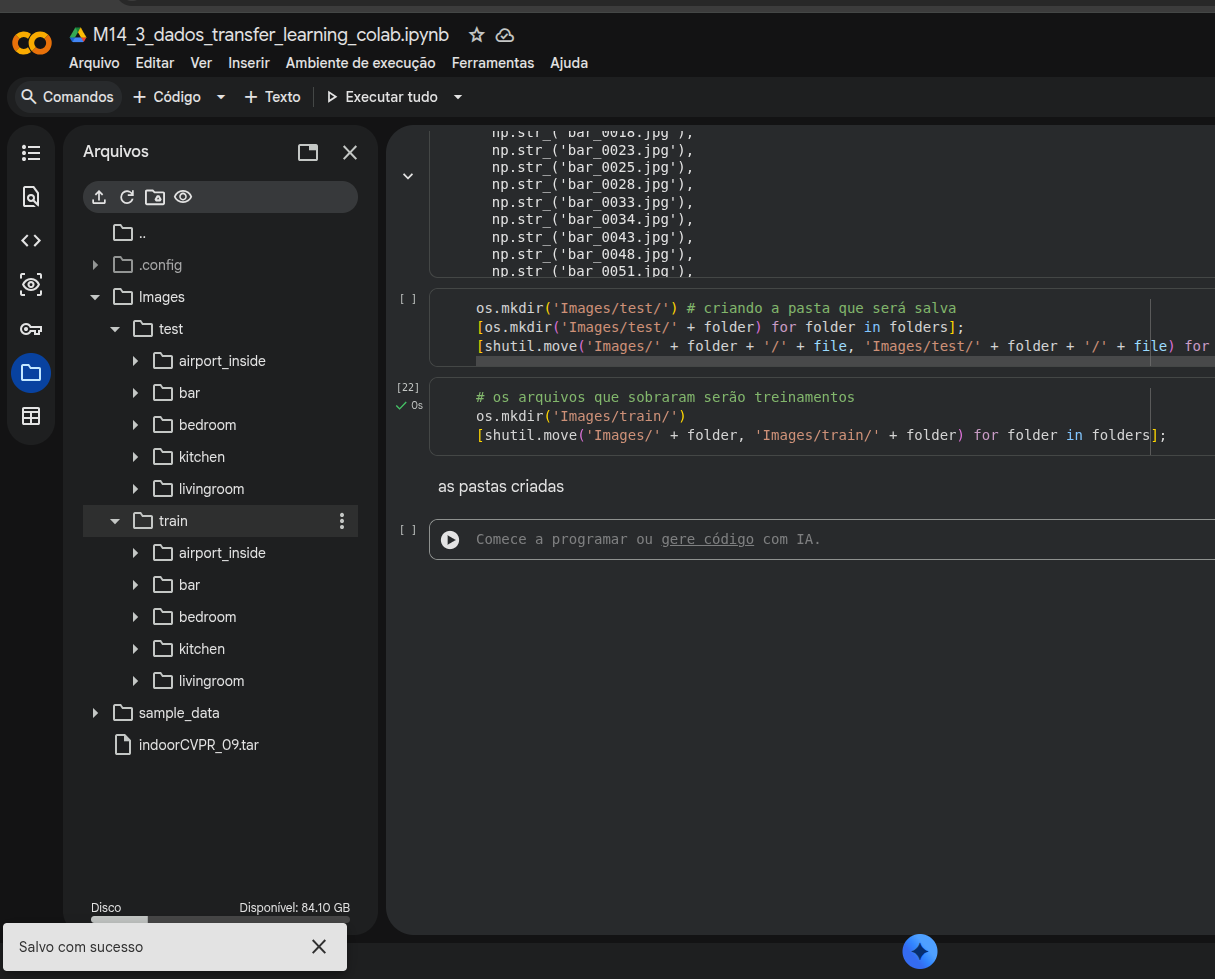

In [25]:
os.rename('Images', 'dataset')